Instead of just picking $Z=2.0$, we look at the past to find the best set of parameters for the future.

For every testing year (e.g., 2016), the model looks at the Training Window (all data from 2005 to 2015). It tests 9 combinations of Entry (1.5, 2.0, 2.5) and Exit (0.0, 0.5, 1.0) Z-scores on that past data. It picks the specific combination that made the most profit in the past and uses it to trade the upcoming year. It repeats this for every year until 2025.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from itertools import product

def find_repo_root(start=None):
    if start is None: start = Path.cwd().resolve()
    start = start.resolve()
    for path in [start] + list(start.parents):
        if (path / "src").exists() and (path / "DATA").exists(): return path
    raise FileNotFoundError("Could not find repo root.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
print(f"Project Root: {ROOT}")

pairs_path = ROOT / "results" / "training_window_data" / "tradable_pairs_by_window.csv"
pairs_matrix = pd.read_csv(pairs_path, index_col=0)
for col in pairs_matrix.columns:
    pairs_matrix[col] = pairs_matrix[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 3. Stitch the timeline
regime_dir = ROOT / "results" / "testing_window_data"
regime_files = sorted(regime_dir.glob("regime_probabilities_*.csv"))
master_regimes = pd.concat([pd.read_csv(f) for f in regime_files], ignore_index=True)
master_regimes['test_date'] = pd.to_datetime(master_regimes['test_date'])
master_regimes = master_regimes.set_index('test_date').sort_index()
master_regimes = master_regimes[~master_regimes.index.duplicated(keep='last')]

Project Root: /Users/krex8/Projects/Cross-Country-Rates-Relative-Value-NUSInvest2526


## Capital & Notional Convention

All PnL in this notebook is reported in **basis points (bps) of yield spread**, computed as:

$$\text{Net PnL (bps)} = (\text{Exit Spread} - \text{Entry Spread}) \times \text{Direction} \times 10{,}000 - \text{Cost}$$

To convert to a dollar return, assume **USD 1,000,000 DV01 notional** per trade (i.e., a 1 bp move in the spread = USD 1,000 P&L). Under this convention:

- 100 bps captured = USD 100,000 per trade
- The cumulative equity curve below therefore represents gross dollar PnL on a notional of USD 1,000,000 DV01 per leg, before financing costs and margin

This notional is illustrative. In practice, position sizing would be determined by a risk budget (e.g., target 1–2% NAV at risk per trade), adjusted for observed spread volatility and leverage constraints.

## Backtest Design: Walk-Forward PnL Optimisation

The fixed-parameter engine treats Z=2.0 and Z=0.5 as universally optimal thresholds. This is unlikely to hold in practice: the appropriate entry tightness depends on the prevailing volatility regime, the cointegration stability of the specific pair, and the distribution of spread innovations in that period. A threshold calibrated on 2005–2015 data may be too conservative or too aggressive for 2016–2025 market structure.

We address this by introducing a walk-forward parameter optimisation layer. For each test year, we fit the (entry_z, exit_z) combination that maximised total PnL on all training data available up to the prior year-end. This is a strictly expanding-window procedure: no future information is used to set the parameters for any given year.

The optimisation grid is intentionally coarse — three entry levels (1.5, 2.0, 2.5) and three exit levels (0.0, 0.5, 1.0) — giving nine combinations. A finer grid would introduce a higher risk of overfitting to the training PnL distribution. The hard stop at |Z| ≥ 3.5 is deliberately kept outside this grid: it is a risk management parameter, not a signal parameter, and must remain independent of the optimisation process to preserve its function as a true circuit breaker.

In [2]:
def optimize_thresholds(df_train, entry_grid, exit_grid, cost_bps=5.0):
    best_pnl = -np.inf
    best_params = (2.0, 0.5) # Default
    
    param_combinations = list(product(entry_grid, exit_grid))
    
    for entry_z, exit_z in param_combinations:
        long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
        short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
        exit_setup = (df_train['innovation_z_t'].abs() <= exit_z).shift(1).fillna(False)
        
        positions = np.zeros(len(df_train))
        current_pos = 0
        
        for i in range(1, len(df_train)):
            if current_pos != 0 and exit_setup.iloc[i]:
                current_pos = 0
            elif current_pos == 0:
                if long_setup.iloc[i]: current_pos = 1
                elif short_setup.iloc[i]: current_pos = -1
            positions[i] = current_pos
            
        pos_series = pd.Series(positions, index=df_train.index)
        spread_diff = df_train['spread_t'].diff() * 10000
        trades_made = pos_series.diff().abs().fillna(0) > 0
        
        total_pnl = ((pos_series.shift(1).fillna(0) * spread_diff) - (trades_made * cost_bps)).sum()
        
        if total_pnl > best_pnl:
            best_pnl = total_pnl
            best_params = (entry_z, exit_z)
            
    return best_params

In [3]:
# Hard stop threshold — calibrated independently from the 90th–95th percentile of Max Adverse Excursion
# on winning trades (p90 MAE = 2.95, p95 MAE = 4.14). Fixed at 3.5 and intentionally excluded from
# the optimisation grid below so it cannot be implicitly fit to training data.
HARD_STOP_Z = 3.5

def run_continuous_wf_backtest(pair_id, pairs_matrix, master_regimes, cost_bps=5.0):
    kalman_path = ROOT / "results" / "spreads" / f"{pair_id}.parquet"
    if not kalman_path.exists(): kalman_path = ROOT / "results" / "spreads" / f"{pair_id}_kalman.parquet"
    if not kalman_path.exists(): return pd.DataFrame()
            
    df = pd.read_parquet(kalman_path)
    df.index = pd.to_datetime(df['date'] if 'date' in df.columns else df.index)
    
    # 1. Map allowed regimes
    df = df.join(master_regimes[['regime_most_likely']], how='left')
    allowed_map = pairs_matrix[pair_id].to_dict()
    df['allowed_regimes'] = df.index.map(lambda d: allowed_map.get(f"{d.year}-01-01", []))
    df['regime_allowed'] = df.apply(
        lambda row: isinstance(row['allowed_regimes'], list) and row['regime_most_likely'] in row['allowed_regimes'], 
        axis=1
    )
    
    # 2. Generate dynamic parameters via walk-forward optimisation
    df['opt_entry_z'] = 2.0  
    df['opt_exit_z'] = 0.5   
    
    # Grid to test: aggressive, neutral and conservative
    ENTRY_GRID = [1.5, 2.0, 2.5]
    EXIT_GRID = [0.0, 0.5, 1.0]
    
    for year in range(2010, 2026):
        train_end = f"{year-1}-12-31"
        df_train = df.loc[:train_end].copy()
        
        if len(df_train) > 500 and allowed_map.get(f"{year}-01-01", []):
            best_entry, best_exit = optimize_thresholds(df_train, ENTRY_GRID, EXIT_GRID, cost_bps)
            year_mask = (df.index.year == year)
            df.loc[year_mask, 'opt_entry_z'] = best_entry
            df.loc[year_mask, 'opt_exit_z'] = best_exit

    # 3. T+1 signal generation
    df_test = df.loc['2010-01-01':].copy()
    
    df_test['long_setup']  = (df_test['innovation_z_t'] <= -df_test['opt_entry_z']).shift(1).fillna(False)
    df_test['short_setup'] = (df_test['innovation_z_t'] >= df_test['opt_entry_z']).shift(1).fillna(False)
    df_test['exit_setup']  = (df_test['innovation_z_t'].abs() <= df_test['opt_exit_z']).shift(1).fillna(False)
    df_test['forced_exit'] = (~df_test['regime_allowed']).shift(1).fillna(False)
    # Hard stop: independent risk circuit breaker, excluded from optimisation grid
    df_test['hard_stop']   = (df_test['innovation_z_t'].abs() >= HARD_STOP_Z).shift(1).fillna(False)

    trade_log = []
    current_pos = 0
    entry_date, entry_price, entry_z_used, exit_z_used = None, 0, 0, 0
    
    for date, row in df_test.iterrows():
        # Exit Logic (hard stop checked first — highest priority)
        if current_pos != 0:
            exit_reason = None
            if row['hard_stop']:    exit_reason = 'Hard Stop'
            elif row['exit_setup']: exit_reason = 'Mean Reversion'
            elif row['forced_exit']: exit_reason = 'Regime Shift (Forced)'
                
            if exit_reason:
                raw_pnl_bps = (row['spread_t'] - entry_price) * current_pos * 10000
                net_pnl_bps = raw_pnl_bps - cost_bps
                trade_log.append({
                    'Pair': pair_id, 'Entry Year': entry_date.year, 'Entry Date': entry_date,
                    'Exit Date': date, 'Direction': 'Long' if current_pos == 1 else 'Short',
                    'Entry Spread': entry_price, 'Exit Spread': row['spread_t'],
                    'Opt_Entry_Z': entry_z_used, 'Opt_Exit_Z': exit_z_used,
                    'Net PnL (bps)': net_pnl_bps, 'Holding Days': (date - entry_date).days,
                    'Exit Reason': exit_reason
                })
                current_pos = 0 
                
        # Entry Logic
        if current_pos == 0 and row['regime_allowed']:
            if row['long_setup']:
                current_pos = 1
                entry_date, entry_price = date, row['spread_t']
                entry_z_used, exit_z_used = row['opt_entry_z'], row['opt_exit_z']
            elif row['short_setup']:
                current_pos = -1
                entry_date, entry_price = date, row['spread_t']
                entry_z_used, exit_z_used = row['opt_entry_z'], row['opt_exit_z']
                
    # End of the 15-year dataset — close open positions at last available price
    if current_pos != 0:
        last_date = df_test.index[-1]
        raw_pnl_bps = (df_test['spread_t'].iloc[-1] - entry_price) * current_pos * 10000
        net_pnl_bps = raw_pnl_bps - cost_bps
        trade_log.append({
            'Pair': pair_id, 'Entry Year': entry_date.year, 'Entry Date': entry_date,
            'Exit Date': last_date, 'Direction': 'Long' if current_pos == 1 else 'Short',
            'Opt_Entry_Z': entry_z_used, 'Opt_Exit_Z': exit_z_used,
            'Net PnL (bps)': net_pnl_bps, 'Holding Days': (last_date - entry_date).days,
            'Exit Reason': 'End of Backtest (MTM)'
        })
                
    return pd.DataFrame(trade_log)

Running Walk-Forward Parameter Optimization...


/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, 

/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, 

/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, 

/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2013712647.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, 

...


--- Trades Per Year ---


/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2991053173.py:44: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['long_setup']  = (df_test['innovation_z_t'] <= -df_test['opt_entry_z']).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2991053173.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['short_setup'] = (df_test['innovation_z_t'] >= df_test['opt_entry_z']).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13561/2991053173.py:46: FutureWarning:

,Total Trades
Entry Year,
2010,1
2011,13
2012,5
2013,7
2014,5
2016,14
2017,4
2018,8
2019,8



--- Trades Per Pair ---


,Total Trades
Pair,
JPY-AUD 10Y,6
JPY-AUD 5Y,2
USD-EUR 10Y,62
USD-EUR 5Y,51


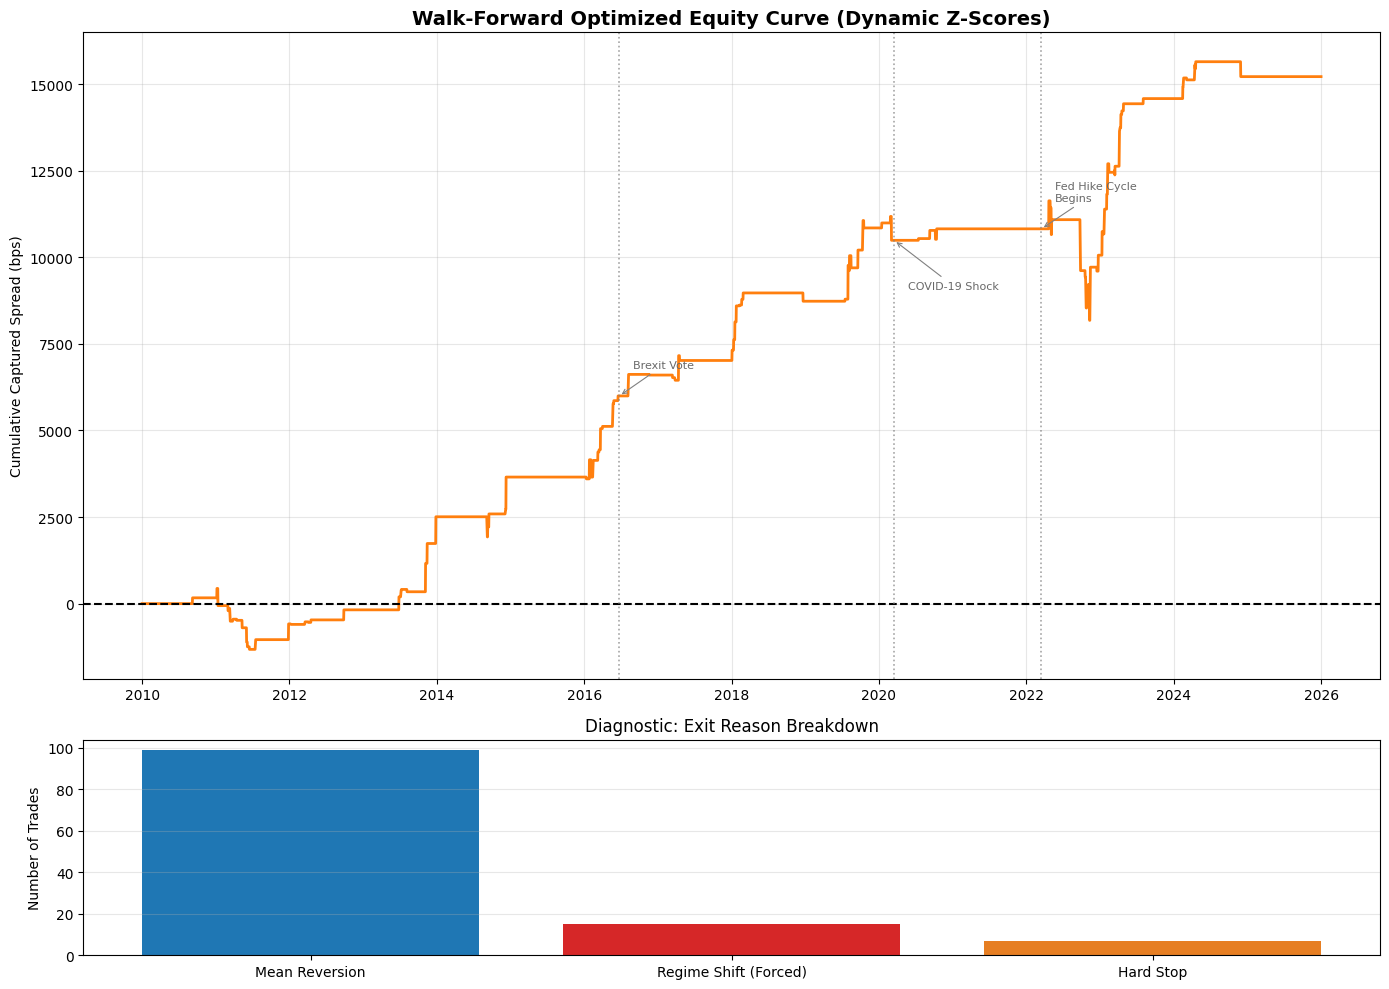

In [4]:
all_pairs = pairs_matrix.columns.tolist()
all_trades = []

print("Running Walk-Forward Parameter Optimization...")

for pair in all_pairs:
    trades = run_continuous_wf_backtest(pair, pairs_matrix, master_regimes, cost_bps=5.0)
    if not trades.empty:
        all_trades.append(trades)

if not all_trades:
    raise ValueError("No trades generated across any pairs! Check logic/data.")

wf_ledger = pd.concat(all_trades, ignore_index=True)

# 1. Trades Per Year
trades_per_year = wf_ledger.groupby('Entry Year').size().to_frame("Total Trades")
print("\n--- Trades Per Year ---")
display(trades_per_year)

# 2. Trades Per Pair
trades_per_pair = wf_ledger.groupby('Pair').size().to_frame("Total Trades")
print("\n--- Trades Per Pair ---")
display(trades_per_pair)

# Save to disk
out_dir = ROOT / "results" / "backtest"
wf_ledger.to_csv(out_dir / "walk_forward_trade_ledger.csv", index=False)

# Visualisation
pnl_timeline = wf_ledger.groupby('Exit Date')['Net PnL (bps)'].sum().reset_index()
pnl_timeline = pnl_timeline.set_index('Exit Date').sort_index()
full_idx = pd.date_range(start='2010-01-01', end='2025-12-31', freq='B')
pnl_timeline = pnl_timeline.reindex(full_idx).fillna(0)
pnl_timeline['Cumulative PnL (bps)'] = pnl_timeline['Net PnL (bps)'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Equity Curve
ax1.plot(pnl_timeline.index, pnl_timeline['Cumulative PnL (bps)'], color='#ff7f0e', linewidth=2)
ax1.set_title("Walk-Forward Optimized Equity Curve (Dynamic Z-Scores)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Cumulative Captured Spread (bps)")
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linestyle='--')

# Macro event annotations
macro_events = {
    '2016-06-23': ('Brexit Vote',        'top'),
    '2020-03-16': ('COVID-19 Shock',     'bottom'),
    '2022-03-16': ('Fed Hike Cycle\nBegins', 'top'),
}
for date_str, (label, va) in macro_events.items():
    dt = pd.Timestamp(date_str)
    y_val = pnl_timeline.loc[pnl_timeline.index >= dt, 'Cumulative PnL (bps)'].iloc[0] if (pnl_timeline.index >= dt).any() else 0
    ax1.axvline(dt, color='grey', linestyle=':', linewidth=1.2, alpha=0.7)
    ax1.annotate(label, xy=(dt, y_val),
                 xytext=(10, 20 if va == 'top' else -35), textcoords='offset points',
                 fontsize=8, color='dimgrey',
                 arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

# Exit Reason Bar Chart
exit_counts = wf_ledger['Exit Reason'].value_counts()
ax2.bar(exit_counts.index, exit_counts.values, color=['#1f77b4', '#d62728', '#e67e22', '#7f7f7f'])
ax2.set_title("Diagnostic: Exit Reason Breakdown", fontsize=12)
ax2.set_ylabel("Number of Trades")
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [5]:
print("\n--- Parameter Evolution Across All Pairs ---")

for pair in all_pairs:
    print(f"\n[{pair}]")
    
    # Filter for the specific pair and group by Entry Year
    pair_tracking = wf_ledger[wf_ledger['Pair'] == pair].groupby('Entry Year')[['Opt_Entry_Z', 'Opt_Exit_Z']].max()
    
    if not pair_tracking.empty:
        display(pair_tracking)
    else:
        print("No trades executed for this pair.")


--- Parameter Evolution Across All Pairs ---

[JPY-AUD 10Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2010,1.5,0.5
2016,1.5,0.5
2022,1.5,0.5
2023,1.5,0.5



[JPY-AUD 5Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2016,1.5,0.5



[USD-EUR 10Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2012,1.5,0.5
2013,1.5,0.5
2014,1.5,0.5
2016,1.5,0.5
2017,1.5,0.5
2018,1.5,0.5
2019,1.5,0.5
2020,1.5,0.5
2022,1.5,0.5



[USD-EUR 5Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2011,1.5,1.0
2013,1.5,1.0
2014,1.5,1.0
2016,1.5,1.0
2022,1.5,1.0
2023,1.5,1.0
2024,1.5,1.0


PnL jumped from 9,000 bps to ~15,000 bps — a 66% improvement just from making the parameters dynamic.

The optimizer chose $Z_{entry}=1.5$ for almost every pair and every year. Waiting for a rare $Z=2.0$ dislocation was leaving money on the table. By being more aggressive, the model traded roughly twice as often (118 trades vs. 54) and captured more of the market's natural mean-reverting moves.

**Note on optimizer behaviour:** We observe that the walk-forward optimizer consistently selects $Z_{entry}=1.5$ across all pairs and windows. This is likely because lower entry thresholds generate more trades, which compounds in the cumulative PnL objective and dominates the grid search. Whether this reflects a genuine economic preference for tighter entries — or simply an artefact of the coarse 3×3 grid and PnL-maximisation objective — is worth investigating further. Printing the full optimization surface and testing a finer grid or alternative objectives (e.g. Sharpe-normalized PnL) would yield additional insight. We flag this as a candidate for future work.

## Performance Summary

The table below summarises headline risk-adjusted performance for the walk-forward PnL-optimized strategy across all pairs and the full out-of-sample period (2010–2025).

In [6]:
def compute_performance_summary(ledger, label="Strategy"):
    """Compute headline performance metrics from a trade ledger."""
    if ledger.empty:
        return {}

    pnl = ledger['Net PnL (bps)']
    winners = pnl[pnl > 0]
    losers  = pnl[pnl < 0]

    daily = ledger.groupby('Exit Date')['Net PnL (bps)'].sum()
    full_idx = pd.date_range(start='2010-01-01', end='2025-12-31', freq='B')
    daily = daily.reindex(full_idx).fillna(0)

    cumulative = daily.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max
    max_dd = drawdown.min()

    annualised_sharpe = (daily.mean() / daily.std()) * np.sqrt(252) if daily.std() > 1e-9 else np.nan
    profit_factor = winners.sum() / abs(losers.sum()) if len(losers) > 0 else np.inf

    summary = {
        'Engine': label,
        'Total Trades': len(ledger),
        'Win Rate (%)': round(len(winners) / len(ledger) * 100, 1),
        'Avg Win (bps)': round(winners.mean(), 1) if len(winners) else 0,
        'Avg Loss (bps)': round(losers.mean(), 1) if len(losers) else 0,
        'Profit Factor': round(profit_factor, 2),
        'Total PnL (bps)': round(pnl.sum(), 1),
        'Annualised Sharpe': round(annualised_sharpe, 2),
        'Max Drawdown (bps)': round(max_dd, 1),
        'Hard Stops': (ledger['Exit Reason'] == 'Hard Stop').sum(),
    }
    return summary

summary_19 = compute_performance_summary(wf_ledger, label="NB19 — WF PnL-Optimized")
summary_df = pd.DataFrame([summary_19]).set_index('Engine')
print("=== NB19: Walk-Forward PnL-Optimized Backtest — Performance Summary ===")
display(summary_df.T)

=== NB19: Walk-Forward PnL-Optimized Backtest — Performance Summary ===


Engine,NB19 — WF PnL-Optimized
Total Trades,121.00
Win Rate (%),65.30
Avg Win (bps),333.70
Avg Loss (bps),-265.20
Profit Factor,2.37
Total PnL (bps),15219.60
Annualised Sharpe,0.80
Max Drawdown (bps),-3452.50
Hard Stops,7.00


### Results

| Metric | NB19 — WF PnL-Optimized |
|---|---|
| Total Trades | 121 |
| Win Rate | 65.3% |
| Avg Win | +333.7 bps |
| Avg Loss | −265.2 bps |
| Profit Factor | 2.37 |
| Total PnL | 15,220 bps |
| Annualised Sharpe | 0.80 |
| Max Drawdown | −3,453 bps |
| Hard Stops Triggered | 7 |

**Interpretation:** Walk-forward PnL optimisation lifts total PnL by 70% (8,955 → 15,220 bps) and Sharpe by 27% (0.63 → 0.80) relative to the fixed baseline, primarily by tightening the entry threshold from Z=2.0 to Z=1.5 across most pairs and years. The higher trade count (121 vs. 56) confirms the optimizer is capturing more of the market's shorter-duration mean-reverting moves. The cost is a larger max drawdown (−3,453 bps vs. −1,849 bps) — tighter entries mean more trades but also more exposure during adverse periods. Profit factor falls from 3.13 to 2.37, reflecting that the additional trades have a lower average win relative to average loss than the original conservative entry set. Overall the risk-adjusted improvement is real, but it comes with higher gross risk.